In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [2]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [3]:


SNRs = [0.1, 0.3, 1, 3, 10, 30]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20


for SNR in SNRs:
    SNR_partition = np.linspace(0, 1, 5)
    for s in SNR_partition:
        A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
        A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
        #mu_1, mu_2 = np.random.randint(0, 100, 2)
        for _ in range(5):
            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 250


for params in pattern_params:
    
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
   
    A1, DX1, bias1, A2, DX2, bias2 = params 
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
        
                    # 1 -> + +
                    # 2 -> - -
                """elif y[i]<5:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    sign = 3-2*(y[i]-2)
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 3 -> + +
                    # 4 -> + -
                else:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 5 -> - -
      
                  """
    #Show_data2D(x)
    model = BM.build_model(L, n_class=n_class)

    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
        
    print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])}")

/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done for 0.0, 20, 0.3440000116825104
Done for 0.0, 20, 0.3409999907016754
Done for 0.0, 20, 0.3440000116825104
Done for 0.0, 20, 0.3564999997615814
Done for 0.0, 20, 0.35249999165534973
Done for 7.118427544235445, 20, 0.33250001072883606
Done for 7.118427544235445, 20, 0.351500004529953
Done for 7.118427544235445, 20, 0.3395000100135803
Done for 7.118427544235445, 20, 0.335999995470047
Done for 7.118427544235445, 20, 0.3555000126361847
Done for 10.066976775827971, 20, 0.33899998664855957
Done for 10.066976775827971, 20, 0.3449999988079071
Done for 10.066976775827971, 20, 0.34599998593330383
Done for 10.066976775827971, 20, 0.3555000126361847
Done for 10.066976775827971, 20, 0.34850001335144043
Done for 12.329478176613542, 20, 0.3490000069141388
Done for 12.329478176613542, 20, 0.34850001335144043
Done for 12.329478176613542, 20, 0.36000001430511475
Done for 12.329478176613542, 20, 0.3440000116825104
Done for 12.329478176613542, 20, 0.3499999940395355
Done for 14.23685508847089, 20, 0.3

In [4]:
accuracy_2D = np.array(acc)
import pickle
with open("accuracy_2D.pkl", "wb") as f:
    pickle.dump(accuracy_2D, f)

In [5]:
print(accuracy_2D)

[0.34400001 0.34099999 0.34400001 0.3565     0.35249999 0.33250001
 0.3515     0.33950001 0.336      0.35550001 0.33899999 0.345
 0.34599999 0.35550001 0.34850001 0.34900001 0.34850001 0.36000001
 0.34400001 0.34999999 0.3335     0.34599999 0.347      0.34400001
 0.34150001 0.33849999 0.35499999 0.3425     0.3495     0.359
 0.3405     0.35800001 0.3515     0.34999999 0.3585     0.34799999
 0.347      0.361      0.35350001 0.36000001 0.34850001 0.36849999
 0.35600001 0.3545     0.36899999 0.36050001 0.35049999 0.34799999
 0.34200001 0.36149999 0.41499999 0.4005     0.4025     0.40599999
 0.4215     0.39449999 0.3635     0.37149999 0.3725     0.39700001
 0.35949999 0.384      0.38699999 0.373      0.36950001 0.3795
 0.3865     0.391      0.38249999 0.36899999 0.3795     0.39750001
 0.39899999 0.41600001 0.41150001 0.58999997 0.60299999 0.60399997
 0.58950001 0.61799997 0.54000002 0.51849997 0.53049999 0.55500001
 0.52249998 0.458      0.4975     0.4975     0.48199999 0.48699999
 0.549000

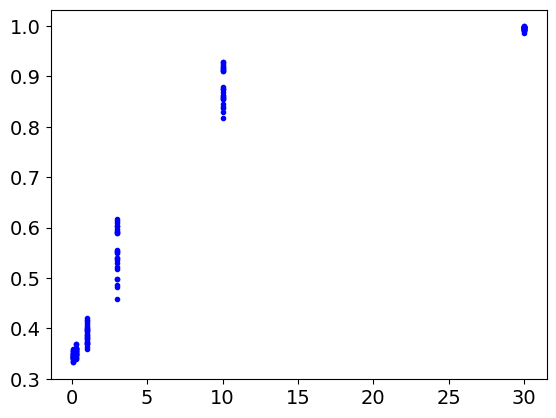

In [6]:
pattern_params = np.array(pattern_params)

snr_g = np.pi**3 / (2 * (np.pi + 4) * d * sigma**2) * (pattern_params[:, 0]**2 + pattern_params[:, 3]**2)

plt.plot(snr_g, accuracy_2D, "b.")

In [7]:
accuracy_reshaped = np.reshape(accuracy_2D, (30, 5))
accuracy_mean = np.mean(accuracy_reshaped, axis=1)
accuracy_std = np.std(accuracy_reshaped, axis=1)

[0.34602 0.35326 0.38918 0.55306 0.88022 0.99538]
1.3435968919348538
0.9261007531509059
7.292951986921544
18.059991591336313
19.56615098774507
15.127126855636579
62.31591906672526


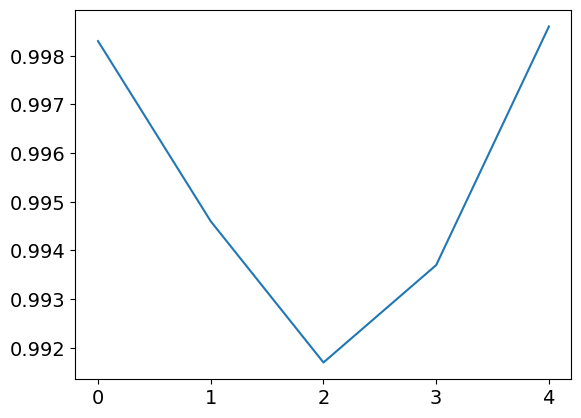

In [9]:
abs_mean = np.mean(np.reshape(accuracy_mean, (6, 5)), axis=1)
abs_std = np.std(np.reshape(accuracy_mean, (6, 5)), axis=1)/5**0.5

chi = 0

plt.plot(range(5), np.reshape(accuracy_mean, (6, 5))[5])
print(abs_mean)
for g in range(6):
    chi_group = 0
    for i in range(5):
        chi += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2 + abs_std[g]**2)
        chi_group += (accuracy_mean[g*5 + i] - abs_mean[g])**2/(accuracy_std[g*5 + i]**2 + abs_std[g]**2)
    print(chi_group)

print(chi)

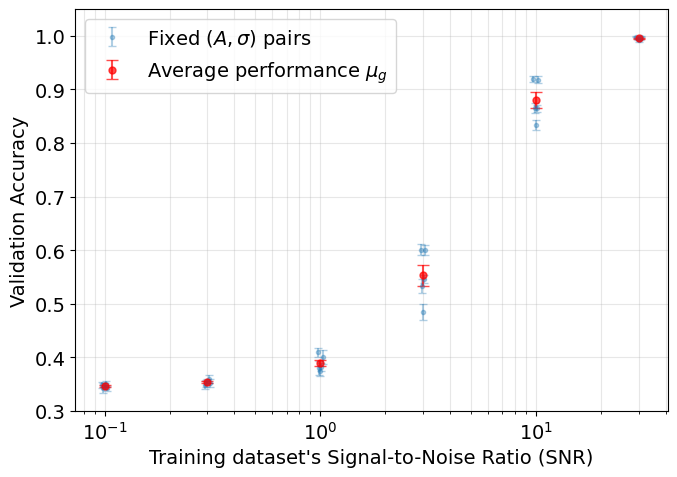

In [10]:


fig, ax = plt.subplots(figsize=(7,5))
SNRs = [0.1, 0.3, 1, 3, 10, 30]

# jitter leggero per evitare overlap
tmp = [
    snr * (1 + delta)
    for snr in SNRs
    for delta in np.linspace(-0.025, 0.025, 5)
]

# risultati delle singole configurazioni
ax.errorbar(
    tmp,
    accuracy_mean,
    yerr=accuracy_std,
    fmt='.',
    capsize=3,
    alpha=0.35,
    label='Fixed $(A,\\sigma)$ pairs'
)

# media globale
ax.errorbar(
    SNRs,
    abs_mean,
    yerr=abs_std,
    fmt='o',
    color="red",
    capsize=4,
    linewidth=1.5,
    markersize=5,
    label=r'Average performance $\mu_g$',
    alpha=0.7
    
)

# asse logaritmico
ax.set_xscale('log')

# labels
ax.set_xlabel("Training dataset's Signal-to-Noise Ratio (SNR)")
ax.set_ylabel("Validation Accuracy")

# limiti utili
ax.set_ylim(0.3, 1.05)

# griglia leggibile
ax.grid(True, which="both", alpha=0.3)

# legenda
ax.legend()

plt.tight_layout()
plt.savefig("accuracy_plot.png", bbox_inches="tight")
plt.show()